In [2]:
import os
os.environ["R_HOME"] = "/homes/kbalzer/miniconda3/envs/qiime2-amplicon-2026.1/lib/R"

qiime_env = "/homes/kbalzer/miniconda3/envs/qiime2-amplicon-2026.1"
os.environ["PATH"] = f"{qiime_env}/bin:/usr/local/bin:/usr/bin:/bin"
os.environ["CONDA_PREFIX"] = qiime_env

In [4]:
import zipfile
import tempfile
from pathlib import Path

import pandas as pd
from biom import load_table

import ancombc2_heatmaps.plotter as plotter_mod

def load_qza_table_as_df_no_qiime2(qza_fp):
    qza_fp = Path(qza_fp)

    with tempfile.TemporaryDirectory() as tmpdir:
        with zipfile.ZipFile(qza_fp, "r") as zf:
            zf.extractall(tmpdir)

        tmpdir = Path(tmpdir)

        biom_files = list(tmpdir.rglob("feature-table.biom"))
        if not biom_files:
            biom_files = list(tmpdir.rglob("*.biom"))

        if not biom_files:
            raise FileNotFoundError(f"No biom file found inside {qza_fp}")

        biom_fp = biom_files[0]
        table = load_table(str(biom_fp))
        df = table.to_dataframe(dense=True)

        df.index = df.index.astype(str)
        df.columns = df.columns.astype(str)
        return df

# monkeypatch im Paket ersetzen
plotter_mod.load_qza_table_as_df = load_qza_table_as_df_no_qiime2

print("Patched ancombc2_heatmaps.plotter.load_qza_table_as_df successfully.")

Patched ancombc2_heatmaps.plotter.load_qza_table_as_df successfully.


In [6]:
from pathlib import Path
import matplotlib.pyplot as plt

from ancombc2_heatmaps import (
    ANCOMBC2HeatmapPlotter,
    HeatmapConfig,
    MetadataConfig,
    ComparisonConfig,
    PathConfig,
    SubsetSpec,
)

# =========================================================
# PATHS
# =========================================================

BASE = Path("/vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/ANCOM_tumour")
META = BASE / "metadata_microbian2_tumour_23.04.2026.txt"

COLLAPSED_BASE = BASE / "collapsed_tables"
ANCOM_BASE = BASE / "exported"
GENUS_TABLE_BASE = Path("/vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/heatmaps_genus_by_timepoint")

OUT = BASE / "tumour_notebook_exports"
OUT.mkdir(exist_ok=True)

HEATMAP_ROOT = OUT / "heatmaps_fixed"
HEATMAP_ROOT.mkdir(parents=True, exist_ok=True)

print("BASE exists:", BASE.exists())
print("META exists:", META.exists())
print("COLLAPSED_BASE exists:", COLLAPSED_BASE.exists())
print("ANCOM_BASE exists:", ANCOM_BASE.exists())
print("GENUS_TABLE_BASE exists:", GENUS_TABLE_BASE.exists())
print("HEATMAP_ROOT exists:", HEATMAP_ROOT.exists())

# =========================================================
# GLOBAL SETTINGS
# =========================================================

TIMEPOINTS = [
    "baseline1", "baseline2", "baseline3",
    "day1", "day3", "day7", "day14"
]

TIMEPOINT_MAP = {
    "baseline_1": "baseline1",
    "baseline_2": "baseline2",
    "baseline_3": "baseline3",
    "day_1_post": "day1",
    "day_3_post": "day3",
    "day_7_post": "day7",
    "day_14_post": "day14",
    "baseline1": "baseline1",
    "baseline2": "baseline2",
    "baseline3": "baseline3",
    "day1": "day1",
    "day3": "day3",
    "day7": "day7",
    "day14": "day14",
}

COMMON_ALLOWED = {
    "description_of_treatment": ["sham", "irradiated"],
    "sex": ["male", "female"],
    "mice_model": ["Apc"],
    "tumour_count_dicho": ["high", "low"],
}

comparison_setup = {
    "comparison_col": "tumour_count_dicho",
    "variable_name": "tumour_count_dicho",
    "positive_class": "high",
    "negative_class": "low",
    "exported_subdir": "tumour_count_dicho",
    "subsets": [
        ("all", "all Apc samples"),
        ("male_alltreat", "male | treatment pooled"),
        ("female_alltreat", "female | treatment pooled"),
        ("sham_allsex", "sham | sex pooled"),
        ("irradiated_allsex", "irradiated | sex pooled"),
        ("male_sham", "male | sham"),
        ("male_irradiated", "male | irradiated"),
        ("female_sham", "female | sham"),
        ("female_irradiated", "female | irradiated"),
    ],
}

taxonomy_levels = ["genus", "family", "phylum"]

# =========================================================
# HELPERS
# =========================================================

def make_heatmap_config(level):
    if level == "genus":
        table_base = GENUS_TABLE_BASE
    else:
        table_base = COLLAPSED_BASE / level / "by_tumour_count_dicho"

    ancom_base = ANCOM_BASE / level / comparison_setup["exported_subdir"]

    outdir = HEATMAP_ROOT / level
    outdir.mkdir(parents=True, exist_ok=True)

    return HeatmapConfig(
        metadata=MetadataConfig(
            sample_col="sample_name",
            timepoint_col="time_point",
            comparison_col=comparison_setup["comparison_col"],
            timepoints=TIMEPOINTS,
            timepoint_map=TIMEPOINT_MAP,
            allowed_values=COMMON_ALLOWED,
        ),
        comparison=ComparisonConfig(
            variable_name=comparison_setup["variable_name"],
            positive_class=comparison_setup["positive_class"],
            negative_class=comparison_setup["negative_class"],
        ),
        paths=PathConfig(
            base_table_dir=str(table_base),
            base_ancom_dir=str(ancom_base),
            metadata_path=str(META),
            output_dir=str(outdir),
            table_template="{timepoint}/table_{timepoint}_{subset_label}.qza",
            ancom_template="{timepoint}/table_{timepoint}_{subset_label}_ANCOMBC2_exported",
        ),
        cell_text_mode="relative_abundance",
        split_after_timepoint="baseline3",
        min_sig_cells_per_taxon=1,
    )

def make_subset(level, subset_prefix, title):
    if level == "genus":
        # eindeutiger Name fürs Speichern
        label = f"{subset_prefix}_genus_ANCOM"
    else:
        label = f"{subset_prefix}_{level}_ANCOM"

    return SubsetSpec(
        label=label,
        title=f"{title} | {level} | tumour_count_dicho",
        filters={}
    )

# =========================================================
# RUN ALL HEATMAP EXPORTS
# =========================================================

for level in taxonomy_levels:
    print(f"\n=== HEATMAPS | level={level} | comparison=tumour_count_dicho ===")

    cfg = make_heatmap_config(level)
    plotter = ANCOMBC2HeatmapPlotter(cfg)
    meta_df = plotter.load_metadata()

    for subset_prefix, title in comparison_setup["subsets"]:
        subset = make_subset(level, subset_prefix, title)

        if level == "genus":
            # genus: Tabellen liegen direkt als table_{timepoint}_ANCOM.qza vor
            plotter.config.paths.table_template = "table_{timepoint}_ANCOM.qza"
            plotter.config.paths.ancom_template = (
                "{timepoint}/table_{timepoint}_" + subset_prefix + "_genus_ANCOMBC2_exported"
            )
        else:
            plotter.config.paths.table_template = "{timepoint}/table_{timepoint}_{subset_label}.qza"
            plotter.config.paths.ancom_template = (
                "{timepoint}/table_{timepoint}_{subset_label}_ANCOMBC2_exported"
            )

        print(f"[HEATMAP] {level} | {subset_prefix}")

        plotter.plot_subset(
            meta_df=meta_df,
            subset=subset,
            show=False,
            save_png=True,
            save_pdf=False,
        )

        plt.close("all")

print("\nAll tumour heatmaps finished.")
print("Saved in:", HEATMAP_ROOT)

BASE exists: True
META exists: True
COLLAPSED_BASE exists: True
ANCOM_BASE exists: True
GENUS_TABLE_BASE exists: True
HEATMAP_ROOT exists: True

=== HEATMAPS | level=genus | comparison=tumour_count_dicho ===
[HEATMAP] genus | all
Saved: /vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/ANCOM_tumour/tumour_notebook_exports/heatmaps_fixed/genus/ancombc2_lfc_heatmap_tumour_count_dicho_all_genus_ANCOM_min1sig.png
[HEATMAP] genus | male_alltreat
Saved: /vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/ANCOM_tumour/tumour_notebook_exports/heatmaps_fixed/genus/ancombc2_lfc_heatmap_tumour_count_dicho_male_alltreat_genus_ANCOM_min1sig.png
[HEATMAP] genus | female_alltreat
Saved: /vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/ANCOM_tumour/tumour_notebook_exports/heatmaps_fixed/genus/ancombc2_lfc_heatmap_tumour_count_dicho_female_alltreat_genus_ANCOM_min1sig.png
[HEATMAP] genus | sham_allsex
Saved: /vol/jlab/MicrobiomeAnalyses/Project

In [7]:
import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import qiime2
from biom import Table
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter

# =========================================================
# PATHS
# =========================================================

BASE = Path("/vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/ANCOM_tumour")
META = BASE / "metadata_microbian2_tumour_23.04.2026.txt"

COLLAPSED_BASE = BASE / "collapsed_tables"
ANCOM_BASE = BASE / "exported"
GENUS_TABLE_BASE = Path("/vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/heatmaps_genus_by_timepoint")

OUT = BASE / "tumour_notebook_exports"
TRAJ_ROOT = OUT / "trajectories"
TRAJ_ROOT.mkdir(parents=True, exist_ok=True)

# =========================================================
# SETTINGS
# =========================================================

TIMEPOINTS = [
    "baseline1", "baseline2", "baseline3",
    "day1", "day3", "day7", "day14"
]

TIMEPOINT_NUMERIC_MAP = {
    "baseline_1": -7,
    "baseline_2": -4,
    "baseline_3": -1,
    "day_1_post": 1,
    "day_3_post": 3,
    "day_7_post": 7,
    "day_14_post": 14,
    "baseline1": -7,
    "baseline2": -4,
    "baseline3": -1,
    "day1": 1,
    "day3": 3,
    "day7": 7,
    "day14": 14,
}

TP_LABEL_MAP = {
    -7: "baseline1",
    -4: "baseline2",
    -1: "baseline3",
    1: "day1",
    3: "day3",
    7: "day7",
    14: "day14",
}

COMMON_ALLOWED = {
    "description_of_treatment": ["sham", "irradiated"],
    "sex": ["female", "male"],
    "mice_model": ["Apc"],
    "tumour_count_dicho": ["high", "low"],
}

# =========================================================
# TAXA TO PLOT
# =========================================================

genus_taxa = [
    "g_Akkermansia",
    "g_Muribaculum",
]

family_taxa = [
    "f_Akkermansiaceae",
    "f_Lachnospiraceae",
    "f_Muribaculaceae",
]

phylum_taxa = [
    "p_Bacteroidota",
    "p_Verrucomicrobiota",
    "p_Actinomycetota",
]

TAXA_BY_LEVEL = {
    "genus": genus_taxa,
    "family": family_taxa,
    "phylum": phylum_taxa,
}

trajectory_comparison_setup = {
    "comparison_col": "tumour_count_dicho",
    "comparison_levels": ["low", "high"],
    "line_styles": {"low": "", "high": (4, 2)},
    "subset_specs": [
        ("all", "all Apc samples", {}),
        ("male_alltreat", "male | treatment pooled", {"sex": "male"}),
        ("female_alltreat", "female | treatment pooled", {"sex": "female"}),
        ("sham_allsex", "sham | sex pooled", {"description_of_treatment": "sham"}),
        ("irradiated_allsex", "irradiated | sex pooled", {"description_of_treatment": "irradiated"}),
        ("male_sham", "male | sham", {"sex": "male", "description_of_treatment": "sham"}),
        ("male_irradiated", "male | irradiated", {"sex": "male", "description_of_treatment": "irradiated"}),
        ("female_sham", "female | sham", {"sex": "female", "description_of_treatment": "sham"}),
        ("female_irradiated", "female | irradiated", {"sex": "female", "description_of_treatment": "irradiated"}),
    ],
}

sns.set_theme(style="whitegrid", context="talk")

RANK_TO_PREFIX = {
    "d": "d__",
    "k": "k__",
    "p": "p__",
    "c": "c__",
    "o": "o__",
    "f": "f__",
    "g": "g__",
}

def clean_float_formatter(x, pos):
    return f"{x:.4f}".rstrip("0").rstrip(".")

def load_qza_table_as_df(qza_fp):
    import zipfile
    import tempfile
    from pathlib import Path
    from biom import load_table

    qza_fp = Path(qza_fp)
    with tempfile.TemporaryDirectory() as tmpdir:
        with zipfile.ZipFile(qza_fp, "r") as zf:
            zf.extractall(tmpdir)

        tmpdir = Path(tmpdir)
        biom_files = list(tmpdir.rglob("feature-table.biom"))
        if not biom_files:
            biom_files = list(tmpdir.rglob("*.biom"))
        if not biom_files:
            raise FileNotFoundError(f"No biom file found inside {qza_fp}")

        table = load_table(str(biom_files[0]))
        df = table.to_dataframe(dense=True)
        df.index = df.index.astype(str)
        df.columns = df.columns.astype(str)
        return df

def clean_tax_piece(x):
    if x is None:
        return None
    x = str(x).strip()
    return x if x else None

def is_empty_tax(x):
    if x is None:
        return True
    stripped = re.sub(r"^[a-z]__+", "", str(x)).strip().lower()
    return stripped in {"", "uncultured", "unclassified", "unknown", "ambiguous_taxa"}

def normalize_taxon_label(raw_tax):
    if raw_tax is None:
        return "_; _; _"

    if isinstance(raw_tax, (list, tuple)):
        parts = [clean_tax_piece(x) for x in raw_tax]
    else:
        parts = [clean_tax_piece(x) for x in str(raw_tax).split(";")]

    parts = [x for x in parts if x is not None]

    tax_map = {}
    for p in parts:
        p = p.strip()
        if "__" in p:
            prefix = p.split("__", 1)[0].lower()
            if not is_empty_tax(p):
                tax_map[prefix] = p

    top_rank = None
    for rank in ["o", "c", "p", "k", "d"]:
        if rank in tax_map:
            top_rank = tax_map[rank]
            break

    family = tax_map.get("f")
    genus = tax_map.get("g")

    if top_rank is None:
        top_rank = "_"
    if family is None:
        family = "_"
    if genus is None:
        genus = "_"

    return f"{top_rank}; {family}; {genus}"

def parse_label(label):
    p = [x.strip() for x in str(label).split(";")]
    while len(p) < 3:
        p.append("_")
    return {"top": p[0], "family": p[1], "genus": p[2]}

def normalize_query(q):
    q = q.strip()
    if ";" in q:
        return {"mode": "exact", "value": q}
    m = re.match(r"([a-zA-Z])_(.+)", q)
    if m:
        r, name = m.group(1).lower(), m.group(2)
        return {"mode": "rank", "rank": r, "value": RANK_TO_PREFIX[r] + name}
    raise ValueError("Invalid taxon_query")

def match_taxa(index, query):
    spec = normalize_query(query)
    matches = []
    for lab in index:
        parsed = parse_label(lab)
        if spec["mode"] == "exact":
            if lab == spec["value"]:
                matches.append(lab)
        else:
            r = spec["rank"]
            if r == "f" and parsed["family"] == spec["value"]:
                matches.append(lab)
            elif r == "g" and parsed["genus"] == spec["value"]:
                matches.append(lab)
            elif r in ["o", "c", "p", "k", "d"] and parsed["top"] == spec["value"]:
                matches.append(lab)
    return matches

def detect_effect_col(df, variable_name):
    candidates = [c for c in df.columns if c.startswith(f"{variable_name}::")]
    return candidates[0] if candidates else None

def sig_to_label(is_sig):
    return "*" if is_sig else "ns"

def load_meta():
    m = pd.read_csv(META, sep="\t", dtype=str)
    m["tp"] = m["time_point"].map(TIMEPOINT_NUMERIC_MAP)
    for col in m.columns:
        if m[col].dtype == object:
            m[col] = m[col].astype(str).str.strip()
    for col, allowed in COMMON_ALLOWED.items():
        m = m[m[col].isin(allowed)].copy()
    return m

def apply_filters(df, filters):
    out = df.copy()
    for col, val in filters.items():
        out = out[out[col] == val].copy()
    return out

def get_table_qza_path(level, tp, subset_prefix):
    if level == "genus":
        return GENUS_TABLE_BASE / f"table_{tp}_ANCOM.qza"
    return COLLAPSED_BASE / level / "by_tumour_count_dicho" / tp / f"table_{tp}_{subset_prefix}_{level}_ANCOM.qza"

def get_ancom_export_dir(level, tp, subset_prefix):
    return ANCOM_BASE / level / "tumour_count_dicho" / tp / f"table_{tp}_{subset_prefix}_{level}_ANCOMBC2_exported"

def build_df_for_subset(meta, level, subset_prefix, subset_filters, taxon_query):
    rows = []
    comparison_col = trajectory_comparison_setup["comparison_col"]
    comparison_levels = trajectory_comparison_setup["comparison_levels"]

    meta_subset = apply_filters(meta, subset_filters)
    meta_subset = meta_subset[meta_subset[comparison_col].isin(comparison_levels)].copy()

    for tp in TIMEPOINTS:
        fp = get_table_qza_path(level, tp, subset_prefix)
        if not fp.exists():
            continue

        df = load_qza_table_as_df(fp)
        df.index = [normalize_taxon_label(x) for x in df.index]
        df = df.groupby(df.index).sum()

        col_sums = df.sum(axis=0)
        col_sums[col_sums == 0] = np.nan
        rel = df.div(col_sums, axis=1)

        matches = match_taxa(rel.index, taxon_query)
        if not matches:
            continue

        vals = rel.loc[matches].sum()
        tp_num = TIMEPOINT_NUMERIC_MAP.get(tp)

        m = meta_subset.copy()
        m = m[m["tp"] == tp_num]
        m = m[m["sample_name"].isin(vals.index)]

        for _, r in m.iterrows():
            rows.append([r["host_subject_id"], r[comparison_col], r["tp"], vals.get(r["sample_name"], np.nan)])

    return pd.DataFrame(rows, columns=["mouse", "group", "tp", "abundance"]).dropna()

def build_sig_map(level, subset_prefix, taxon_query, q_cutoff=0.05):
    sig_map = {}
    variable_name = "tumour_count_dicho"

    for tp in TIMEPOINTS:
        export_dir = get_ancom_export_dir(level, tp, subset_prefix)
        q_fp = export_dir / "q.jsonl"
        diff_fp = export_dir / "diff.jsonl"

        if not (export_dir.exists() and q_fp.exists() and diff_fp.exists()):
            continue

        q = pd.read_json(q_fp, lines=True)
        diff = pd.read_json(diff_fp, lines=True)

        effect_col = detect_effect_col(q, variable_name)
        if effect_col is None or effect_col not in diff.columns:
            continue

        tax_col_q = "taxon" if "taxon" in q.columns else q.columns[0]
        tax_col_diff = "taxon" if "taxon" in diff.columns else diff.columns[0]

        q_sub = q[[tax_col_q, effect_col]].rename(columns={tax_col_q: "taxon_raw", effect_col: "q"})
        diff_sub = diff[[tax_col_diff, effect_col]].rename(columns={tax_col_diff: "taxon_raw", effect_col: "diff"})

        tmp = q_sub.merge(diff_sub, on="taxon_raw", how="inner").copy()
        tmp["taxon"] = tmp["taxon_raw"].apply(normalize_taxon_label)
        tmp["significant"] = (tmp["q"] < q_cutoff) & (tmp["diff"] == True)

        sig_by_taxon = tmp.groupby("taxon", as_index=True)["significant"].any()
        matches = match_taxa(sig_by_taxon.index, taxon_query)
        tp_num = TIMEPOINT_NUMERIC_MAP.get(tp)

        sig_map[tp_num] = bool(sig_by_taxon.loc[matches].any()) if matches and tp_num is not None else False

    return sig_map

def apply_baseline(df, merge_baselines=False):
    df = df.copy()
    df["tp_plot"] = df["tp"]
    return df

def compute_ylim(dfs, estimator="mean", error_style="iqr"):
    upper_bounds = []
    for df in dfs:
        if df.empty:
            continue
        for _, g in df.groupby(["tp_plot", "group"]):
            vals = pd.to_numeric(g["abundance"], errors="coerce").dropna().to_numpy()
            if len(vals) == 0:
                continue
            center = np.mean(vals) if estimator == "mean" else np.median(vals)
            upper = np.percentile(vals, 75) if error_style == "iqr" else center
            upper_bounds.append(max(center, upper))
    if not upper_bounds:
        return (0, 1)
    ymax = max(upper_bounds)
    return (0, ymax * 1.03 if ymax > 0 else 1)

def get_visible_upper(g, estimator="mean", error_style="iqr"):
    uppers = []
    for _, gs in g.groupby("group"):
        vals = pd.to_numeric(gs["abundance"], errors="coerce").dropna().to_numpy()
        if len(vals) == 0:
            continue
        upper = np.percentile(vals, 75) if error_style == "iqr" else np.mean(vals)
        center = np.mean(vals) if estimator == "mean" else np.median(vals)
        uppers.append(max(center, upper))
    return max(uppers) if uppers else np.nan

def sanitize_filename(s):
    return str(s).replace(" ", "_").replace("|", "_").replace("/", "_")

def save_trajectory_plot(df, title, comparison_levels, line_styles, out_fp,
                         sig_map=None, estimator="mean", error_style="iqr",
                         show_individual_lines=True, y_label="relative abundance"):
    if df.empty:
        print(f"[SKIP] No data: {title}")
        return

    df = apply_baseline(df)
    ylim = compute_ylim([df], estimator=estimator, error_style=error_style)

    fig, ax = plt.subplots(figsize=(12, 8))
    dashes = line_styles if line_styles else True

    if show_individual_lines:
        sns.lineplot(
            data=df, x="tp_plot", y="abundance",
            hue="group", style="group", dashes=dashes,
            units="mouse", estimator=None, alpha=0.35,
            linewidth=1, legend=False, ax=ax
        )

    sns.lineplot(
        data=df, x="tp_plot", y="abundance",
        hue="group", style="group", dashes=dashes,
        estimator=estimator, errorbar=("pi", 50),
        marker="o", linewidth=2.5,
        hue_order=comparison_levels, style_order=comparison_levels, ax=ax
    )

    ax.set_title(f"{title}\n(mean ± IQR)", pad=15)
    ax.set_ylabel(y_label)
    ax.set_xlabel("")
    ax.yaxis.set_major_formatter(FuncFormatter(clean_float_formatter))

    tp_vals = sorted(df["tp_plot"].dropna().unique())
    tp_labels = [TP_LABEL_MAP.get(tp, str(tp)) for tp in tp_vals]
    ax.set_xticks(tp_vals)
    ax.set_xticklabels(tp_labels, rotation=35, ha="right")
    ax.set_ylim(ylim)

    if sig_map is not None:
        y0, y1 = ax.get_ylim()
        y_range = y1 - y0
        offset = y_range * 0.012
        for tp_plot in sorted(df["tp_plot"].dropna().unique()):
            g = df[df["tp_plot"] == tp_plot]
            visible_upper = get_visible_upper(g, estimator=estimator, error_style=error_style)
            if pd.isna(visible_upper):
                continue
            original_tps = sorted(pd.to_numeric(g["tp"], errors="coerce").dropna().unique())
            is_sig = any(sig_map.get(int(tp_num), False) for tp_num in original_tps)
            label = sig_to_label(is_sig)
            y = min(visible_upper + offset, y1 - y_range * 0.03)
            ax.text(tp_plot, y, label, ha="center", va="bottom", fontsize=11)

    handles, labels = ax.get_legend_handles_labels()
    seen = set()
    clean_handles = []
    clean_labels = []
    for h, l in zip(handles, labels):
        if l not in seen:
            clean_handles.append(h)
            clean_labels.append(l)
            seen.add(l)

    if sig_map is not None:
        star_legend = Line2D([0], [0], color="black", lw=0, label="* ANCOM significant\nns : not significant")
        clean_handles.append(star_legend)
        clean_labels.append(star_legend.get_label())

    ax.legend(handles=clean_handles, labels=clean_labels, loc="upper left", fontsize=10, frameon=True, framealpha=0.9)

    out_fp = Path(out_fp)
    out_fp.parent.mkdir(parents=True, exist_ok=True)
    plt.tight_layout()
    plt.savefig(out_fp, dpi=300, bbox_inches="tight")
    plt.close(fig)

meta = load_meta()

for level, taxa_list in TAXA_BY_LEVEL.items():
    outdir = TRAJ_ROOT / level
    outdir.mkdir(parents=True, exist_ok=True)

    print(f"\n=== TRAJ | level={level} | comparison=tumour_count_dicho ===")

    for subset_prefix, subset_title, subset_filters in trajectory_comparison_setup["subset_specs"]:
        for taxon_query in taxa_list:
            df = build_df_for_subset(
                meta=meta,
                level=level,
                subset_prefix=subset_prefix,
                subset_filters=subset_filters,
                taxon_query=taxon_query,
            )

            sig_map = build_sig_map(
                level=level,
                subset_prefix=subset_prefix,
                taxon_query=taxon_query,
            )

            fname = f"{sanitize_filename(taxon_query)}__{sanitize_filename(level)}__tumour_count_dicho__{sanitize_filename(subset_prefix)}.png"

            save_trajectory_plot(
                df=df,
                title=f"{taxon_query} — {subset_title} | {level} | tumour_count_dicho",
                comparison_levels=trajectory_comparison_setup["comparison_levels"],
                line_styles=trajectory_comparison_setup["line_styles"],
                out_fp=outdir / fname,
                sig_map=sig_map,
                estimator="mean",
                error_style="iqr",
                show_individual_lines=True,
                y_label="relative abundance",
            )

print("\nAll tumour trajectories finished.")
print("Saved in:", TRAJ_ROOT)


=== TRAJ | level=genus | comparison=tumour_count_dicho ===
[SKIP] No data: g_Akkermansia — all Apc samples | genus | tumour_count_dicho
[SKIP] No data: g_Muribaculum — all Apc samples | genus | tumour_count_dicho
[SKIP] No data: g_Akkermansia — male | treatment pooled | genus | tumour_count_dicho
[SKIP] No data: g_Muribaculum — male | treatment pooled | genus | tumour_count_dicho
[SKIP] No data: g_Akkermansia — female | treatment pooled | genus | tumour_count_dicho
[SKIP] No data: g_Muribaculum — female | treatment pooled | genus | tumour_count_dicho
[SKIP] No data: g_Akkermansia — sham | sex pooled | genus | tumour_count_dicho
[SKIP] No data: g_Muribaculum — sham | sex pooled | genus | tumour_count_dicho
[SKIP] No data: g_Akkermansia — irradiated | sex pooled | genus | tumour_count_dicho
[SKIP] No data: g_Muribaculum — irradiated | sex pooled | genus | tumour_count_dicho
[SKIP] No data: g_Akkermansia — male | sham | genus | tumour_count_dicho
[SKIP] No data: g_Muribaculum — male | sh

BASE exists: True
META exists: True
COLLAPSED_BASE exists: True
ANCOM_BASE exists: True
GENUS_TABLE_BASE exists: True
TRAJ_ROOT exists: True

=== TRAJ | level=genus | comparison=tumour_count_dicho ===
[SKIP] No data: g_Akkermansia — all Apc samples | genus | tumour_count_dicho
[SKIP] No data: g_Muribaculum — all Apc samples | genus | tumour_count_dicho
[SKIP] No data: g_Akkermansia — male | treatment pooled | genus | tumour_count_dicho
[SKIP] No data: g_Muribaculum — male | treatment pooled | genus | tumour_count_dicho
[SKIP] No data: g_Akkermansia — female | treatment pooled | genus | tumour_count_dicho
[SKIP] No data: g_Muribaculum — female | treatment pooled | genus | tumour_count_dicho
[SKIP] No data: g_Akkermansia — sham | sex pooled | genus | tumour_count_dicho
[SKIP] No data: g_Muribaculum — sham | sex pooled | genus | tumour_count_dicho
[SKIP] No data: g_Akkermansia — irradiated | sex pooled | genus | tumour_count_dicho
[SKIP] No data: g_Muribaculum — irradiated | sex pooled | 

KeyboardInterrupt: 

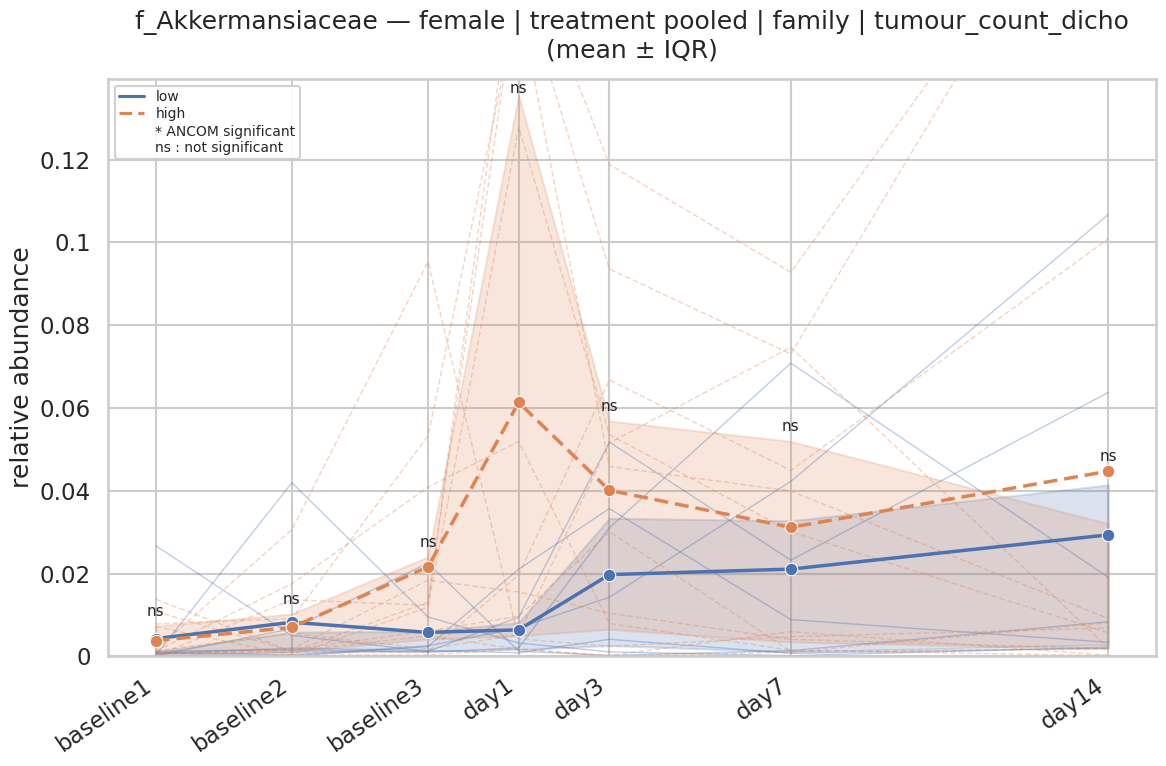

In [12]:
import os
import re
import zipfile
import tempfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from biom import load_table
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter

# =========================================================
# PATHS
# =========================================================

BASE = Path("/vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/ANCOM_tumour")
META = BASE / "metadata_microbian2_tumour_23.04.2026.txt"

COLLAPSED_BASE = BASE / "collapsed_tables"
ANCOM_BASE = BASE / "exported"
GENUS_TABLE_BASE = Path("/vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/heatmaps_genus_by_timepoint")

OUT = BASE / "tumour_notebook_exports"
TRAJ_ROOT = OUT / "trajectories_fixed"
TRAJ_ROOT.mkdir(parents=True, exist_ok=True)

print("BASE exists:", BASE.exists())
print("META exists:", META.exists())
print("COLLAPSED_BASE exists:", COLLAPSED_BASE.exists())
print("ANCOM_BASE exists:", ANCOM_BASE.exists())
print("GENUS_TABLE_BASE exists:", GENUS_TABLE_BASE.exists())
print("TRAJ_ROOT exists:", TRAJ_ROOT.exists())

# =========================================================
# SETTINGS
# =========================================================

TIMEPOINTS = [
    "baseline1", "baseline2", "baseline3",
    "day1", "day3", "day7", "day14"
]

TIMEPOINT_NUMERIC_MAP = {
    "baseline_1": -7,
    "baseline_2": -4,
    "baseline_3": -1,
    "day_1_post": 1,
    "day_3_post": 3,
    "day_7_post": 7,
    "day_14_post": 14,
    "baseline1": -7,
    "baseline2": -4,
    "baseline3": -1,
    "day1": 1,
    "day3": 3,
    "day7": 7,
    "day14": 14,
}

TP_LABEL_MAP = {
    -7: "baseline1",
    -4: "baseline2",
    -1: "baseline3",
    1: "day1",
    3: "day3",
    7: "day7",
    14: "day14",
}

COMMON_ALLOWED = {
    "description_of_treatment": ["sham", "irradiated"],
    "sex": ["female", "male"],
    "mice_model": ["Apc"],
    "tumour_count_dicho": ["high", "low"],
}

# =========================================================
# TAXA TO PLOT
# Hier einfach anpassen
# =========================================================

genus_taxa = [
    "g_Akkermansia",
    "g_Muribaculum",
]

family_taxa = [
    "f_Akkermansiaceae",
    "f_Lachnospiraceae",
    "f_Muribaculaceae",
]

phylum_taxa = [
    "p_Bacteroidota",
    "p_Verrucomicrobiota",
    "p_Actinomycetota",
]

TAXA_BY_LEVEL = {
    "genus": genus_taxa,
    "family": family_taxa,
    "phylum": phylum_taxa,
}

# =========================================================
# COMPARISON SETUP
# =========================================================

trajectory_comparison_setup = {
    "comparison_col": "tumour_count_dicho",
    "comparison_levels": ["low", "high"],
    "line_styles": {"low": "", "high": (4, 2)},
    "subset_specs": [
        ("all", "all Apc samples", {}),
        ("male_alltreat", "male | treatment pooled", {"sex": "male"}),
        ("female_alltreat", "female | treatment pooled", {"sex": "female"}),
        ("sham_allsex", "sham | sex pooled", {"description_of_treatment": "sham"}),
        ("irradiated_allsex", "irradiated | sex pooled", {"description_of_treatment": "irradiated"}),
        ("male_sham", "male | sham", {"sex": "male", "description_of_treatment": "sham"}),
        ("male_irradiated", "male | irradiated", {"sex": "male", "description_of_treatment": "irradiated"}),
        ("female_sham", "female | sham", {"sex": "female", "description_of_treatment": "sham"}),
        ("female_irradiated", "female | irradiated", {"sex": "female", "description_of_treatment": "irradiated"}),
    ],
}

sns.set_theme(style="whitegrid", context="talk")

# =========================================================
# HELPERS
# =========================================================

RANK_TO_PREFIX = {
    "d": "d__",
    "k": "k__",
    "p": "p__",
    "c": "c__",
    "o": "o__",
    "f": "f__",
    "g": "g__",
}

def clean_float_formatter(x, pos):
    return f"{x:.4f}".rstrip("0").rstrip(".")

def load_qza_table_as_df(qza_fp):
    qza_fp = Path(qza_fp)

    with tempfile.TemporaryDirectory() as tmpdir:
        with zipfile.ZipFile(qza_fp, "r") as zf:
            zf.extractall(tmpdir)

        tmpdir = Path(tmpdir)
        biom_files = list(tmpdir.rglob("feature-table.biom"))
        if not biom_files:
            biom_files = list(tmpdir.rglob("*.biom"))

        if not biom_files:
            raise FileNotFoundError(f"No biom file found inside {qza_fp}")

        table = load_table(str(biom_files[0]))
        df = table.to_dataframe(dense=True)
        df.index = df.index.astype(str)
        df.columns = df.columns.astype(str)
        return df

def normalize_taxon_label(raw_tax):
    if raw_tax is None:
        return "_"
    s = str(raw_tax).strip()
    return s if s else "_"

def normalize_query(q):
    q = str(q).strip()

    if ";" in q:
        return {"mode": "exact", "value": q}

    m = re.match(r"([a-zA-Z])_(.+)", q)
    if m:
        rank = m.group(1).lower()
        name = m.group(2).strip()
        if rank not in RANK_TO_PREFIX:
            raise ValueError(f"Unsupported rank prefix: {rank}")
        return {"mode": "rank", "rank": rank, "value": name}

    return {"mode": "substring", "value": q}

def match_taxa(index, query):
    spec = normalize_query(query)
    matches = []

    for lab in index:
        lab_str = str(lab)

        if spec["mode"] == "exact":
            if lab_str == spec["value"]:
                matches.append(lab_str)

        elif spec["mode"] == "rank":
            rank = spec["rank"]
            name = spec["value"]

            candidates = [
                f"{rank}__{name}",
                f"{rank}_{name}",
                name,
            ]

            if any(c in lab_str for c in candidates):
                matches.append(lab_str)

        else:
            if spec["value"] in lab_str:
                matches.append(lab_str)

    return matches

def detect_effect_col(df, variable_name):
    candidates = [c for c in df.columns if c.startswith(f"{variable_name}::")]
    if len(candidates) == 1:
        return candidates[0]
    if len(candidates) > 1:
        return candidates[0]
    return None

def sig_to_label(is_sig):
    return "*" if is_sig else "ns"

def load_meta():
    m = pd.read_csv(META, sep="\t", dtype=str)

    for col in m.columns:
        if m[col].dtype == object:
            m[col] = m[col].astype(str).str.strip()

    m["tp"] = m["time_point"].map(TIMEPOINT_NUMERIC_MAP)

    for col, allowed in COMMON_ALLOWED.items():
        m = m[m[col].isin(allowed)].copy()

    return m

def apply_filters(df, filters):
    out = df.copy()
    for col, val in filters.items():
        if isinstance(val, (list, tuple, set)):
            out = out[out[col].isin(list(val))].copy()
        else:
            out = out[out[col] == val].copy()
    return out

def get_table_qza_path(level, tp, subset_prefix):
    if level == "genus":
        return GENUS_TABLE_BASE / f"table_{tp}_ANCOM.qza"
    else:
        return COLLAPSED_BASE / level / "by_tumour_count_dicho" / tp / f"table_{tp}_{subset_prefix}_{level}_ANCOM.qza"

def get_ancom_export_dir(level, tp, subset_prefix):
    return ANCOM_BASE / level / "tumour_count_dicho" / tp / f"table_{tp}_{subset_prefix}_{level}_ANCOMBC2_exported"

def build_df_for_subset(meta, level, subset_prefix, subset_filters, taxon_query):
    rows = []
    comparison_col = trajectory_comparison_setup["comparison_col"]
    comparison_levels = trajectory_comparison_setup["comparison_levels"]

    meta_subset = apply_filters(meta, subset_filters)
    meta_subset = meta_subset[meta_subset[comparison_col].isin(comparison_levels)].copy()

    for tp in TIMEPOINTS:
        fp = get_table_qza_path(level, tp, subset_prefix)
        if not fp.exists():
            continue

        df = load_qza_table_as_df(fp)
        df.index = [normalize_taxon_label(x) for x in df.index]
        df = df.groupby(df.index).sum()

        col_sums = df.sum(axis=0)
        col_sums[col_sums == 0] = np.nan
        rel = df.div(col_sums, axis=1)

        matches = match_taxa(rel.index, taxon_query)
        if not matches:
            continue

        vals = rel.loc[matches].sum()

        tp_num = TIMEPOINT_NUMERIC_MAP.get(tp)
        m = meta_subset.copy()
        m = m[m["tp"] == tp_num]
        m = m[m["sample_name"].isin(vals.index)]

        for _, r in m.iterrows():
            rows.append([
                r["host_subject_id"],
                r[comparison_col],
                r["tp"],
                vals.get(r["sample_name"], np.nan),
            ])

    return pd.DataFrame(rows, columns=["mouse", "group", "tp", "abundance"]).dropna()

def build_sig_map(level, subset_prefix, taxon_query, q_cutoff=0.05):
    sig_map = {}
    variable_name = "tumour_count_dicho"

    for tp in TIMEPOINTS:
        export_dir = get_ancom_export_dir(level, tp, subset_prefix)
        q_fp = export_dir / "q.jsonl"
        diff_fp = export_dir / "diff.jsonl"

        if not (export_dir.exists() and q_fp.exists() and diff_fp.exists()):
            continue

        q = pd.read_json(q_fp, lines=True)
        diff = pd.read_json(diff_fp, lines=True)

        effect_col = detect_effect_col(q, variable_name)
        if effect_col is None or effect_col not in diff.columns:
            continue

        tax_col_q = "taxon" if "taxon" in q.columns else q.columns[0]
        tax_col_diff = "taxon" if "taxon" in diff.columns else diff.columns[0]

        q_sub = q[[tax_col_q, effect_col]].rename(columns={tax_col_q: "taxon_raw", effect_col: "q"})
        diff_sub = diff[[tax_col_diff, effect_col]].rename(columns={tax_col_diff: "taxon_raw", effect_col: "diff"})

        tmp = q_sub.merge(diff_sub, on="taxon_raw", how="inner").copy()
        tmp["taxon"] = tmp["taxon_raw"].apply(normalize_taxon_label)
        tmp["significant"] = (tmp["q"] < q_cutoff) & (tmp["diff"] == True)

        sig_by_taxon = tmp.groupby("taxon", as_index=True)["significant"].any()

        matches = match_taxa(sig_by_taxon.index, taxon_query)
        tp_num = TIMEPOINT_NUMERIC_MAP.get(tp)

        if len(matches) == 0 or tp_num is None:
            sig_map[tp_num] = False
        else:
            sig_map[tp_num] = bool(sig_by_taxon.loc[matches].any())

    return sig_map

def apply_baseline(df, merge_baselines=False):
    df = df.copy()
    if merge_baselines:
        df["tp_plot"] = df["tp"].replace({
            -7: 0, -4: 0, -1: 0,
            1: 1, 3: 3, 7: 7, 14: 14
        })
    else:
        df["tp_plot"] = df["tp"]
    return df

def compute_ylim(dfs, estimator="mean", error_style="iqr", merge_baselines=False):
    upper_bounds = []

    for df in dfs:
        if df.empty:
            continue

        df_plot = apply_baseline(df, merge_baselines=merge_baselines)

        for _, g in df_plot.groupby(["tp_plot", "group"]):
            vals = pd.to_numeric(g["abundance"], errors="coerce").dropna().to_numpy()
            if len(vals) == 0:
                continue

            center = np.median(vals) if estimator == "median" else np.mean(vals)

            if error_style == "iqr":
                upper = np.percentile(vals, 75)
            else:
                rng = np.random.default_rng(42)
                func = np.median if estimator == "median" else np.mean
                boots = []
                for _ in range(1000):
                    sample = rng.choice(vals, size=len(vals), replace=True)
                    boots.append(func(sample))
                upper = np.percentile(boots, 97.5)

            upper_bounds.append(max(center, upper))

    if not upper_bounds:
        return (0, 1)

    ymax = max(upper_bounds)
    if not np.isfinite(ymax) or ymax <= 0:
        return (0, 1)

    return (0, ymax * 1.03)

def get_visible_upper(g, estimator="mean", error_style="iqr"):
    uppers = []

    for _, gs in g.groupby("group"):
        vals = pd.to_numeric(gs["abundance"], errors="coerce").dropna().to_numpy()
        if len(vals) == 0:
            continue

        if error_style == "iqr":
            upper = np.percentile(vals, 75)
        else:
            rng = np.random.default_rng(42)
            func = np.median if estimator == "median" else np.mean
            boots = []
            for _ in range(1000):
                sample = rng.choice(vals, size=len(vals), replace=True)
                boots.append(func(sample))
            upper = np.percentile(boots, 97.5)

        center = np.median(vals) if estimator == "median" else np.mean(vals)
        uppers.append(max(center, upper))

    if len(uppers) == 0:
        return np.nan

    return max(uppers)

def sanitize_filename(s):
    s = str(s)
    return s.replace(" ", "_").replace("|", "_").replace("/", "_")

def save_trajectory_plot(
    df,
    title,
    comparison_levels,
    line_styles,
    out_fp,
    sig_map=None,
    merge_baselines=False,
    estimator="mean",
    error_style="iqr",
    y_lim="auto_fix",
    show_individual_lines=True,
    y_label="relative abundance",
):
    if df.empty:
        print(f"[SKIP] No data: {title}")
        return

    df = apply_baseline(df, merge_baselines=merge_baselines)
    ylim = compute_ylim([df], estimator=estimator, error_style=error_style, merge_baselines=False) if y_lim == "auto_fix" else y_lim

    fig, ax = plt.subplots(figsize=(12, 8))
    dashes = line_styles if line_styles else True

    if show_individual_lines:
        sns.lineplot(
            data=df,
            x="tp_plot",
            y="abundance",
            hue="group",
            style="group",
            dashes=dashes,
            units="mouse",
            estimator=None,
            alpha=0.35,
            linewidth=1,
            legend=False,
            ax=ax
        )

    error_setting = ("ci", 95) if error_style == "ci" else ("pi", 50)

    sns.lineplot(
        data=df,
        x="tp_plot",
        y="abundance",
        hue="group",
        style="group",
        dashes=dashes,
        estimator=estimator,
        errorbar=error_setting,
        marker="o",
        linewidth=2.5,
        hue_order=comparison_levels,
        style_order=comparison_levels,
        ax=ax
    )

    estimator_label = "median" if estimator == "median" else "mean"
    err_label = "± 95% CI" if error_style == "ci" else "± IQR"

    ax.set_title(f"{title}\n({estimator_label} {err_label})", pad=15)
    ax.set_ylabel(y_label)
    ax.set_xlabel("")
    ax.yaxis.set_major_formatter(FuncFormatter(clean_float_formatter))

    tp_vals = sorted(df["tp_plot"].dropna().unique())
    tp_labels = [TP_LABEL_MAP.get(tp, str(tp)) for tp in tp_vals]
    ax.set_xticks(tp_vals)
    ax.set_xticklabels(tp_labels, rotation=35, ha="right")

    if isinstance(ylim, tuple):
        ax.set_ylim(ylim)

    if sig_map is not None:
        y0, y1 = ax.get_ylim()
        y_range = y1 - y0
        offset = y_range * 0.012

        for tp_plot in sorted(df["tp_plot"].dropna().unique()):
            g = df[df["tp_plot"] == tp_plot]
            visible_upper = get_visible_upper(g, estimator=estimator, error_style=error_style)
            if pd.isna(visible_upper):
                continue

            original_tps = sorted(pd.to_numeric(g["tp"], errors="coerce").dropna().unique())
            if tp_plot == 0 and merge_baselines:
                is_sig = any(sig_map.get(tp_num, False) for tp_num in [-7, -4, -1])
            else:
                is_sig = any(sig_map.get(int(tp_num), False) for tp_num in original_tps)

            label = sig_to_label(is_sig)
            y = min(visible_upper + offset, y1 - y_range * 0.03)
            ax.text(tp_plot, y, label, ha="center", va="bottom", fontsize=11)

    handles, labels = ax.get_legend_handles_labels()
    seen = set()
    clean_handles = []
    clean_labels = []
    for h, l in zip(handles, labels):
        if l not in seen:
            clean_handles.append(h)
            clean_labels.append(l)
            seen.add(l)

    if sig_map is not None:
        star_legend = Line2D(
            [0], [0], color="black", lw=0,
            label="* ANCOM significant\nns : not significant"
        )
        clean_handles.append(star_legend)
        clean_labels.append(star_legend.get_label())

    ax.legend(
        handles=clean_handles,
        labels=clean_labels,
        loc="upper left",
        fontsize=10,
        frameon=True,
        framealpha=0.9,
        borderpad=0.3,
        labelspacing=0.25,
        handlelength=1.8
    )

    out_fp = Path(out_fp)
    out_fp.parent.mkdir(parents=True, exist_ok=True)
    plt.tight_layout()
    plt.savefig(out_fp, dpi=300, bbox_inches="tight")
    plt.close(fig)

# =========================================================
# RUN ALL TRAJECTORY EXPORTS
# =========================================================

meta = load_meta()

for level, taxa_list in TAXA_BY_LEVEL.items():
    outdir = TRAJ_ROOT / level
    outdir.mkdir(parents=True, exist_ok=True)

    print(f"\n=== TRAJ | level={level} | comparison=tumour_count_dicho ===")

    for subset_prefix, subset_title, subset_filters in trajectory_comparison_setup["subset_specs"]:
        for taxon_query in taxa_list:
            df = build_df_for_subset(
                meta=meta,
                level=level,
                subset_prefix=subset_prefix,
                subset_filters=subset_filters,
                taxon_query=taxon_query,
            )

            sig_map = build_sig_map(
                level=level,
                subset_prefix=subset_prefix,
                taxon_query=taxon_query,
            )

            fname = (
                f"{sanitize_filename(taxon_query)}__"
                f"{sanitize_filename(level)}__"
                f"tumour_count_dicho__"
                f"{sanitize_filename(subset_prefix)}.png"
            )

            save_trajectory_plot(
                df=df,
                title=f"{taxon_query} — {subset_title} | {level} | tumour_count_dicho",
                comparison_levels=trajectory_comparison_setup["comparison_levels"],
                line_styles=trajectory_comparison_setup["line_styles"],
                out_fp=outdir / fname,
                sig_map=sig_map,
                merge_baselines=False,
                estimator="mean",
                error_style="iqr",
                y_lim="auto_fix",
                show_individual_lines=True,
                y_label="relative abundance",
            )

print("\nAll tumour trajectories finished.")
print("Saved in:", TRAJ_ROOT)

import os
import re
import zipfile
import tempfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from biom import load_table
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter

# =========================================================
# PATHS
# =========================================================

BASE = Path("/vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/ANCOM_tumour")
META = BASE / "metadata_microbian2_tumour_23.04.2026.txt"

COLLAPSED_BASE = BASE / "collapsed_tables"
ANCOM_BASE = BASE / "exported"
GENUS_TABLE_BASE = Path("/vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/heatmaps_genus_by_timepoint")

OUT = BASE / "tumour_notebook_exports"
TRAJ_ROOT = OUT / "trajectories_fixed"
TRAJ_ROOT.mkdir(parents=True, exist_ok=True)

print("BASE exists:", BASE.exists())
print("META exists:", META.exists())
print("COLLAPSED_BASE exists:", COLLAPSED_BASE.exists())
print("ANCOM_BASE exists:", ANCOM_BASE.exists())
print("GENUS_TABLE_BASE exists:", GENUS_TABLE_BASE.exists())
print("TRAJ_ROOT exists:", TRAJ_ROOT.exists())

# =========================================================
# SETTINGS
# =========================================================

TIMEPOINTS = [
    "baseline1", "baseline2", "baseline3",
    "day1", "day3", "day7", "day14"
]

TIMEPOINT_NUMERIC_MAP = {
    "baseline_1": -7,
    "baseline_2": -4,
    "baseline_3": -1,
    "day_1_post": 1,
    "day_3_post": 3,
    "day_7_post": 7,
    "day_14_post": 14,
    "baseline1": -7,
    "baseline2": -4,
    "baseline3": -1,
    "day1": 1,
    "day3": 3,
    "day7": 7,
    "day14": 14,
}

TP_LABEL_MAP = {
    -7: "baseline1",
    -4: "baseline2",
    -1: "baseline3",
    1: "day1",
    3: "day3",
    7: "day7",
    14: "day14",
}

COMMON_ALLOWED = {
    "description_of_treatment": ["sham", "irradiated"],
    "sex": ["female", "male"],
    "mice_model": ["Apc"],
    "tumour_count_dicho": ["high", "low"],
}

# =========================================================
# TAXA TO PLOT
# Hier einfach anpassen
# =========================================================

genus_taxa = [
    "g_Akkermansia",
    "g_Muribaculum",
]

family_taxa = [
    "f_Akkermansiaceae",
    "f_Lachnospiraceae",
    "f_Muribaculaceae",
]

phylum_taxa = [
    "p_Bacteroidota",
    "p_Verrucomicrobiota",
    "p_Actinomycetota",
]

TAXA_BY_LEVEL = {
    "genus": genus_taxa,
    "family": family_taxa,
    "phylum": phylum_taxa,
}

# =========================================================
# COMPARISON SETUP
# =========================================================

trajectory_comparison_setup = {
    "comparison_col": "tumour_count_dicho",
    "comparison_levels": ["low", "high"],
    "line_styles": {"low": "", "high": (4, 2)},
    "subset_specs": [
        ("all", "all Apc samples", {}),
        ("male_alltreat", "male | treatment pooled", {"sex": "male"}),
        ("female_alltreat", "female | treatment pooled", {"sex": "female"}),
        ("sham_allsex", "sham | sex pooled", {"description_of_treatment": "sham"}),
        ("irradiated_allsex", "irradiated | sex pooled", {"description_of_treatment": "irradiated"}),
        ("male_sham", "male | sham", {"sex": "male", "description_of_treatment": "sham"}),
        ("male_irradiated", "male | irradiated", {"sex": "male", "description_of_treatment": "irradiated"}),
        ("female_sham", "female | sham", {"sex": "female", "description_of_treatment": "sham"}),
        ("female_irradiated", "female | irradiated", {"sex": "female", "description_of_treatment": "irradiated"}),
    ],
}

sns.set_theme(style="whitegrid", context="talk")

# =========================================================
# HELPERS
# =========================================================

RANK_TO_PREFIX = {
    "d": "d__",
    "k": "k__",
    "p": "p__",
    "c": "c__",
    "o": "o__",
    "f": "f__",
    "g": "g__",
}

def clean_float_formatter(x, pos):
    return f"{x:.4f}".rstrip("0").rstrip(".")

def load_qza_table_as_df(qza_fp):
    qza_fp = Path(qza_fp)

    with tempfile.TemporaryDirectory() as tmpdir:
        with zipfile.ZipFile(qza_fp, "r") as zf:
            zf.extractall(tmpdir)

        tmpdir = Path(tmpdir)
        biom_files = list(tmpdir.rglob("feature-table.biom"))
        if not biom_files:
            biom_files = list(tmpdir.rglob("*.biom"))

        if not biom_files:
            raise FileNotFoundError(f"No biom file found inside {qza_fp}")

        table = load_table(str(biom_files[0]))
        df = table.to_dataframe(dense=True)
        df.index = df.index.astype(str)
        df.columns = df.columns.astype(str)
        return df

def normalize_taxon_label(raw_tax):
    if raw_tax is None:
        return "_"
    s = str(raw_tax).strip()
    return s if s else "_"

def normalize_query(q):
    q = str(q).strip()

    if ";" in q:
        return {"mode": "exact", "value": q}

    m = re.match(r"([a-zA-Z])_(.+)", q)
    if m:
        rank = m.group(1).lower()
        name = m.group(2).strip()
        if rank not in RANK_TO_PREFIX:
            raise ValueError(f"Unsupported rank prefix: {rank}")
        return {"mode": "rank", "rank": rank, "value": name}

    return {"mode": "substring", "value": q}

def match_taxa(index, query):
    spec = normalize_query(query)
    matches = []

    for lab in index:
        lab_str = str(lab)

        if spec["mode"] == "exact":
            if lab_str == spec["value"]:
                matches.append(lab_str)

        elif spec["mode"] == "rank":
            rank = spec["rank"]
            name = spec["value"]

            candidates = [
                f"{rank}__{name}",
                f"{rank}_{name}",
                name,
            ]

            if any(c in lab_str for c in candidates):
                matches.append(lab_str)

        else:
            if spec["value"] in lab_str:
                matches.append(lab_str)

    return matches

def detect_effect_col(df, variable_name):
    candidates = [c for c in df.columns if c.startswith(f"{variable_name}::")]
    if len(candidates) == 1:
        return candidates[0]
    if len(candidates) > 1:
        return candidates[0]
    return None

def sig_to_label(is_sig):
    return "*" if is_sig else "ns"

def load_meta():
    m = pd.read_csv(META, sep="\t", dtype=str)

    for col in m.columns:
        if m[col].dtype == object:
            m[col] = m[col].astype(str).str.strip()

    m["tp"] = m["time_point"].map(TIMEPOINT_NUMERIC_MAP)

    for col, allowed in COMMON_ALLOWED.items():
        m = m[m[col].isin(allowed)].copy()

    return m

def apply_filters(df, filters):
    out = df.copy()
    for col, val in filters.items():
        if isinstance(val, (list, tuple, set)):
            out = out[out[col].isin(list(val))].copy()
        else:
            out = out[out[col] == val].copy()
    return out

def get_table_qza_path(level, tp, subset_prefix):
    if level == "genus":
        return GENUS_TABLE_BASE / f"table_{tp}_ANCOM.qza"
    else:
        return COLLAPSED_BASE / level / "by_tumour_count_dicho" / tp / f"table_{tp}_{subset_prefix}_{level}_ANCOM.qza"

def get_ancom_export_dir(level, tp, subset_prefix):
    return ANCOM_BASE / level / "tumour_count_dicho" / tp / f"table_{tp}_{subset_prefix}_{level}_ANCOMBC2_exported"

def build_df_for_subset(meta, level, subset_prefix, subset_filters, taxon_query):
    rows = []
    comparison_col = trajectory_comparison_setup["comparison_col"]
    comparison_levels = trajectory_comparison_setup["comparison_levels"]

    meta_subset = apply_filters(meta, subset_filters)
    meta_subset = meta_subset[meta_subset[comparison_col].isin(comparison_levels)].copy()

    for tp in TIMEPOINTS:
        fp = get_table_qza_path(level, tp, subset_prefix)
        if not fp.exists():
            continue

        df = load_qza_table_as_df(fp)
        df.index = [normalize_taxon_label(x) for x in df.index]
        df = df.groupby(df.index).sum()

        col_sums = df.sum(axis=0)
        col_sums[col_sums == 0] = np.nan
        rel = df.div(col_sums, axis=1)

        matches = match_taxa(rel.index, taxon_query)
        if not matches:
            continue

        vals = rel.loc[matches].sum()

        tp_num = TIMEPOINT_NUMERIC_MAP.get(tp)
        m = meta_subset.copy()
        m = m[m["tp"] == tp_num]
        m = m[m["sample_name"].isin(vals.index)]

        for _, r in m.iterrows():
            rows.append([
                r["host_subject_id"],
                r[comparison_col],
                r["tp"],
                vals.get(r["sample_name"], np.nan),
            ])

    return pd.DataFrame(rows, columns=["mouse", "group", "tp", "abundance"]).dropna()

def build_sig_map(level, subset_prefix, taxon_query, q_cutoff=0.05):
    sig_map = {}
    variable_name = "tumour_count_dicho"

    for tp in TIMEPOINTS:
        export_dir = get_ancom_export_dir(level, tp, subset_prefix)
        q_fp = export_dir / "q.jsonl"
        diff_fp = export_dir / "diff.jsonl"

        if not (export_dir.exists() and q_fp.exists() and diff_fp.exists()):
            continue

        q = pd.read_json(q_fp, lines=True)
        diff = pd.read_json(diff_fp, lines=True)

        effect_col = detect_effect_col(q, variable_name)
        if effect_col is None or effect_col not in diff.columns:
            continue

        tax_col_q = "taxon" if "taxon" in q.columns else q.columns[0]
        tax_col_diff = "taxon" if "taxon" in diff.columns else diff.columns[0]

        q_sub = q[[tax_col_q, effect_col]].rename(columns={tax_col_q: "taxon_raw", effect_col: "q"})
        diff_sub = diff[[tax_col_diff, effect_col]].rename(columns={tax_col_diff: "taxon_raw", effect_col: "diff"})

        tmp = q_sub.merge(diff_sub, on="taxon_raw", how="inner").copy()
        tmp["taxon"] = tmp["taxon_raw"].apply(normalize_taxon_label)
        tmp["significant"] = (tmp["q"] < q_cutoff) & (tmp["diff"] == True)

        sig_by_taxon = tmp.groupby("taxon", as_index=True)["significant"].any()

        matches = match_taxa(sig_by_taxon.index, taxon_query)
        tp_num = TIMEPOINT_NUMERIC_MAP.get(tp)

        if len(matches) == 0 or tp_num is None:
            sig_map[tp_num] = False
        else:
            sig_map[tp_num] = bool(sig_by_taxon.loc[matches].any())

    return sig_map

def apply_baseline(df, merge_baselines=False):
    df = df.copy()
    if merge_baselines:
        df["tp_plot"] = df["tp"].replace({
            -7: 0, -4: 0, -1: 0,
            1: 1, 3: 3, 7: 7, 14: 14
        })
    else:
        df["tp_plot"] = df["tp"]
    return df

def compute_ylim(dfs, estimator="mean", error_style="iqr", merge_baselines=False):
    upper_bounds = []

    for df in dfs:
        if df.empty:
            continue

        df_plot = apply_baseline(df, merge_baselines=merge_baselines)

        for _, g in df_plot.groupby(["tp_plot", "group"]):
            vals = pd.to_numeric(g["abundance"], errors="coerce").dropna().to_numpy()
            if len(vals) == 0:
                continue

            center = np.median(vals) if estimator == "median" else np.mean(vals)

            if error_style == "iqr":
                upper = np.percentile(vals, 75)
            else:
                rng = np.random.default_rng(42)
                func = np.median if estimator == "median" else np.mean
                boots = []
                for _ in range(1000):
                    sample = rng.choice(vals, size=len(vals), replace=True)
                    boots.append(func(sample))
                upper = np.percentile(boots, 97.5)

            upper_bounds.append(max(center, upper))

    if not upper_bounds:
        return (0, 1)

    ymax = max(upper_bounds)
    if not np.isfinite(ymax) or ymax <= 0:
        return (0, 1)

    return (0, ymax * 1.03)

def get_visible_upper(g, estimator="mean", error_style="iqr"):
    uppers = []

    for _, gs in g.groupby("group"):
        vals = pd.to_numeric(gs["abundance"], errors="coerce").dropna().to_numpy()
        if len(vals) == 0:
            continue

        if error_style == "iqr":
            upper = np.percentile(vals, 75)
        else:
            rng = np.random.default_rng(42)
            func = np.median if estimator == "median" else np.mean
            boots = []
            for _ in range(1000):
                sample = rng.choice(vals, size=len(vals), replace=True)
                boots.append(func(sample))
            upper = np.percentile(boots, 97.5)

        center = np.median(vals) if estimator == "median" else np.mean(vals)
        uppers.append(max(center, upper))

    if len(uppers) == 0:
        return np.nan

    return max(uppers)

def sanitize_filename(s):
    s = str(s)
    return s.replace(" ", "_").replace("|", "_").replace("/", "_")

def save_trajectory_plot(
    df,
    title,
    comparison_levels,
    line_styles,
    out_fp,
    sig_map=None,
    merge_baselines=False,
    estimator="mean",
    error_style="iqr",
    y_lim="auto_fix",
    show_individual_lines=True,
    y_label="relative abundance",
):
    if df.empty:
        print(f"[SKIP] No data: {title}")
        return

    df = apply_baseline(df, merge_baselines=merge_baselines)
    ylim = compute_ylim([df], estimator=estimator, error_style=error_style, merge_baselines=False) if y_lim == "auto_fix" else y_lim

    fig, ax = plt.subplots(figsize=(12, 8))
    dashes = line_styles if line_styles else True

    if show_individual_lines:
        sns.lineplot(
            data=df,
            x="tp_plot",
            y="abundance",
            hue="group",
            style="group",
            dashes=dashes,
            units="mouse",
            estimator=None,
            alpha=0.35,
            linewidth=1,
            legend=False,
            ax=ax
        )

    error_setting = ("ci", 95) if error_style == "ci" else ("pi", 50)

    sns.lineplot(
        data=df,
        x="tp_plot",
        y="abundance",
        hue="group",
        style="group",
        dashes=dashes,
        estimator=estimator,
        errorbar=error_setting,
        marker="o",
        linewidth=2.5,
        hue_order=comparison_levels,
        style_order=comparison_levels,
        ax=ax
    )

    estimator_label = "median" if estimator == "median" else "mean"
    err_label = "± 95% CI" if error_style == "ci" else "± IQR"

    ax.set_title(f"{title}\n({estimator_label} {err_label})", pad=15)
    ax.set_ylabel(y_label)
    ax.set_xlabel("")
    ax.yaxis.set_major_formatter(FuncFormatter(clean_float_formatter))

    tp_vals = sorted(df["tp_plot"].dropna().unique())
    tp_labels = [TP_LABEL_MAP.get(tp, str(tp)) for tp in tp_vals]
    ax.set_xticks(tp_vals)
    ax.set_xticklabels(tp_labels, rotation=35, ha="right")

    if isinstance(ylim, tuple):
        ax.set_ylim(ylim)

    if sig_map is not None:
        y0, y1 = ax.get_ylim()
        y_range = y1 - y0
        offset = y_range * 0.012

        for tp_plot in sorted(df["tp_plot"].dropna().unique()):
            g = df[df["tp_plot"] == tp_plot]
            visible_upper = get_visible_upper(g, estimator=estimator, error_style=error_style)
            if pd.isna(visible_upper):
                continue

            original_tps = sorted(pd.to_numeric(g["tp"], errors="coerce").dropna().unique())
            if tp_plot == 0 and merge_baselines:
                is_sig = any(sig_map.get(tp_num, False) for tp_num in [-7, -4, -1])
            else:
                is_sig = any(sig_map.get(int(tp_num), False) for tp_num in original_tps)

            label = sig_to_label(is_sig)
            y = min(visible_upper + offset, y1 - y_range * 0.03)
            ax.text(tp_plot, y, label, ha="center", va="bottom", fontsize=11)

    handles, labels = ax.get_legend_handles_labels()
    seen = set()
    clean_handles = []
    clean_labels = []
    for h, l in zip(handles, labels):
        if l not in seen:
            clean_handles.append(h)
            clean_labels.append(l)
            seen.add(l)

    if sig_map is not None:
        star_legend = Line2D(
            [0], [0], color="black", lw=0,
            label="* ANCOM significant\nns : not significant"
        )
        clean_handles.append(star_legend)
        clean_labels.append(star_legend.get_label())

    ax.legend(
        handles=clean_handles,
        labels=clean_labels,
        loc="upper left",
        fontsize=10,
        frameon=True,
        framealpha=0.9,
        borderpad=0.3,
        labelspacing=0.25,
        handlelength=1.8
    )

    out_fp = Path(out_fp)
    out_fp.parent.mkdir(parents=True, exist_ok=True)
    plt.tight_layout()
    plt.savefig(out_fp, dpi=300, bbox_inches="tight")
    plt.close(fig)

# =========================================================
# RUN ALL TRAJECTORY EXPORTS
# =========================================================

meta = load_meta()

for level, taxa_list in TAXA_BY_LEVEL.items():
    outdir = TRAJ_ROOT / level
    outdir.mkdir(parents=True, exist_ok=True)

    print(f"\n=== TRAJ | level={level} | comparison=tumour_count_dicho ===")

    for subset_prefix, subset_title, subset_filters in trajectory_comparison_setup["subset_specs"]:
        for taxon_query in taxa_list:
            df = build_df_for_subset(
                meta=meta,
                level=level,
                subset_prefix=subset_prefix,
                subset_filters=subset_filters,
                taxon_query=taxon_query,
            )

            sig_map = build_sig_map(
                level=level,
                subset_prefix=subset_prefix,
                taxon_query=taxon_query,
            )

            fname = (
                f"{sanitize_filename(taxon_query)}__"
                f"{sanitize_filename(level)}__"
                f"tumour_count_dicho__"
                f"{sanitize_filename(subset_prefix)}.png"
            )

            save_trajectory_plot(
                df=df,
                title=f"{taxon_query} — {subset_title} | {level} | tumour_count_dicho",
                comparison_levels=trajectory_comparison_setup["comparison_levels"],
                line_styles=trajectory_comparison_setup["line_styles"],
                out_fp=outdir / fname,
                sig_map=sig_map,
                merge_baselines=False,
                estimator="mean",
                error_style="iqr",
                y_lim="auto_fix",
                show_individual_lines=True,
                y_label="relative abundance",
            )

print("\nAll tumour trajectories finished.")
print("Saved in:", TRAJ_ROOT)

In [13]:
from pathlib import Path
import pandas as pd

test_fp = Path("/vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/heatmaps_genus_by_timepoint/table_baseline1_ANCOM.qza")

df = load_qza_table_as_df(test_fp)

print("shape:", df.shape)
print("\nErste 50 rohe Taxonlabels:")
for x in list(df.index[:50]):
    print(repr(x))

labels = sorted({str(x) for x in df.index})

print("\nLabels mit 'Akk':")
for x in labels:
    if "Akk" in x or "akk" in x:
        print(repr(x))

print("\nLabels mit 'Murib':")
for x in labels:
    if "Murib" in x or "murib" in x:
        print(repr(x))

shape: (820, 78)

Erste 50 rohe Taxonlabels:
'TGGGGGATATTGCACAATGGGGGGAACCCTGATGCAGCGACGCCGCGTGAACGAAGAAATATTTCGGTATGTAAAGTTCTATCAGCAGGGAAGAAAATGACAGTACCTGACCAAGAAGCCCCGGCTAACTACGTGCCAGCAGCCGCGGTAATACGGAGGATGCGAGCGTTATCCGGATTTATTGGGTTTAAAGGGTGCGT'
'TTAGGAATATTCGTCAATGGGGGAAACCCTGAACGAGCAATGCCGCGTGAGTGATGAAGGCCCTATGGGTTGTAAAACTCTGTTGTTGAGAAAGAATTGTAAGATTAGGAAATGAGTCTTACTTGACGGTACTCTTCAAGAAAGCCACGGCTAACTACGTGCCAGCAGCCGCGGTAATACGTAGGTGGCGAGCGTTATCC'
'TGGGGAATGAAGGTCTTCGGATTGTAAACCCCTGTCATGTGGGAGCAAATTAAAAAGATAGTACCACAAGAGGAAGAGACGGCTAACTCTGTGCCAGCAGCCGCGGTAATACAGAGGTCTCAAGCGTTGTTCGGAATCACTGGGCGTAAAGCGTGCGTAGGCTGTTTCGTAAGTCGTGTGTGAAAGGCGCGGGCTCAACC'
'TGGGGGATATTGCACAATGGGGGGAACCCTGATGCAGCGACGCCGCGTGGGCGATGGAGCGCCTCGGCGCGTAAAGCCCTATCAGCAGGGAAGAAGATGACGGTACCTGACTAAGAAGCCCCGGCTAAATACGTGCCAGCAGCCGCGGTAATACGGAGGATGCGAGCGTTATCCGGATTTATTGGGTTTAAAGGGTGCGT'
'TGGGGAATATTGCACAATGGGGGAAACCCTGATGCAGCGACGCCGCGTGAGTGAAGAAGTATTTCGGTATGTAAAGCTCTATCAGCAGGGAAGATAATGACGGTACCTGACTAAGAAGCCCCGGCTAACTACGTGCCAGCAG